# Pertemuan 04 — Hands-on 03: Analisis Eksperimental & Visualisasi Representasi CNN
**Mata Kuliah:** Deep Learning (IF25-40401) — Program Studi Teknik Informatika, Institut Teknologi Sumatera (ITERA)  
**Materi:** Visualisasi Feature Map Berhierarki, Komparasi Empiris MLP vs CNN, Uji Invariansi, Studi Ablasi, dan Adaptasi CIFAR-10  
**Alokasi Waktu:** ~45 Menit (Tatap Muka Kelas TM 3×50′)  
**Pemenuhan Silabus RPS:** *"Mahasiswa membangun CNN dari nol dan melatihnya pada dataset gambar, lalu memvisualisasikan feature map untuk memahami representasi hierarkis."*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/informatika-itera/deep-learning-IF25-40401/blob/main/materials/notebooks/03-analisis-eksperimen-cnn.ipynb)

---

### Capaian Pembelajaran (Sub-CPMK)
1. **Sub-CPMK 4:** Membuktikan keunggulan *weight sharing* dan *local connectivity* CNN dibandingkan MLP melalui perbandingan parameter (1,06 juta vs 61 ribu) dan ketahanan terhadap pergeseran (*translation robustness*).
2. **Sub-CPMK 1 & 4:** Memvisualisasikan bobot filter layer konvolusi dan *hierarchical feature maps* (fitur rendah/tepi menuju fitur menengah/pola) menggunakan *PyTorch Forward Hooks*.
3. **Sub-CPMK 2:** Menghitung dan menganalisis *Receptive Field* (RF) analitis serta membuktikan efisiensi filter $3\times3$ bertingkat vs filter $5\times5$.
4. **Sub-CPMK 3 & 4:** Melakukan studi ablasi terkontrol (Tanh vs ReLU, AvgPool vs MaxPool, Stride vs Pooling) serta mengadaptasi model LeNet-5 ke citra warna 3-kanal (CIFAR-10).

---

### Konfigurasi Mode Eksekusi
Notebook ini dilengkapi saklar `MODE_CEPAT = True` agar seluruh eksperimen dapat selesai dalam waktu **≤ 5-10 menit di CPU kelas**. Dosen dapat mengubahnya menjadi `MODE_CEPAT = False` bila ingin melatih pada seluruh dataset penuh.

In [10]:
# Saklar Kecepatan Eksekusi untuk Live-Coding di Kelas
MODE_CEPAT = True  # True: subset data latih (10.000 sampel, 2 epoch) | False: data penuh (60.000 sampel, 5 epoch)

%pip install torchinfo -q

import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from torchinfo import summary

# Reproduktibilitas
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))

print("=" * 65)
print(f"Perangkat Komputasi : {device}")
print(f"Status MODE_CEPAT   : {MODE_CEPAT} (Optimasi TM Kelas)")
print("=" * 65)

/Users/martinmanullang/Developer/dl_web/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
Perangkat Komputasi : mps
Status MODE_CEPAT   : True (Optimasi TM Kelas)


## 1. Persiapan Model LeNet-5 & Checkpoint

Untuk menjaga agar Notebook 3 dapat dijalankan secara mandiri (*self-contained*), kode di bawah akan:
1. Mendefinisikan ulang kelas `LeNet5` (persis dari Notebook 2).
2. Memuat berkas checkpoint `lenet5_mnist.pth` hasil pelatihan Notebook 2 jika tersedia.
3. Bila berkas checkpoint belum ada (misalnya mahasiswa langsung membuka Notebook 3 di Google Colab), sistem akan melatih model selama 2 epoch secara otomatis.

In [11]:
# Definisi arsitektur LeNet-5 persis Notebook 2 & Slide Frame 61-63
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(in_features=16 * 5 * 5, out_features=120),
            nn.Tanh(),
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=10)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits

# Muat dataset MNIST (32x32)
transform_mnist = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

DIR_DATA = "./data"
train_ds_full = datasets.MNIST(root=DIR_DATA, train=True, download=True, transform=transform_mnist)
test_ds = datasets.MNIST(root=DIR_DATA, train=False, download=True, transform=transform_mnist)

# Terapkan subset jika MODE_CEPAT aktif
if MODE_CEPAT:
    indices_sub = list(range(10000))
    train_ds = Subset(train_ds_full, indices_sub)
else:
    train_ds = train_ds_full

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1000, shuffle=False)

# Inisialisasi model LeNet-5
model_lenet = LeNet5().to(device)
PATH_CHECKPOINT = "lenet5_mnist.pth"

if os.path.exists(PATH_CHECKPOINT):
    print(f"Memuat bobot pre-trained dari '{PATH_CHECKPOINT}'...")
    model_lenet.load_state_dict(torch.load(PATH_CHECKPOINT, map_location=device))
    print("✓ Checkpoint berhasil dimuat!")
else:
    print(f"Berkas '{PATH_CHECKPOINT}' tidak ditemukan. Melatih model mini 2 epoch secara otomatis...")
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model_lenet.parameters(), lr=0.001)
    model_lenet.train()
    for ep in range(2):
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            out = model_lenet(imgs)
            l = crit(out, lbls)
            l.backward()
            opt.step()
    print("✓ Pelatihan cepat selesai!")

model_lenet.eval()
print(f"Model LeNet-5 siap digunakan untuk analisis.")

Memuat bobot pre-trained dari 'lenet5_mnist.pth'...
✓ Checkpoint berhasil dimuat!
Model LeNet-5 siap digunakan untuk analisis.


## 2. Head-to-Head: MLP vs CNN (Membuktikan Ledakan Parameter)

Pada slide Pertemuan 04 (*Frame 11*, baris ~280), kita membahas alasan mengapa Multi-Layer Perceptron (MLP) tidak cocok untuk data citra:
- Citra $32 \times 32$ memiliki $1.024$ piksel.
- Sebuah *hidden layer* MLP dengan $1.024$ neuron menghasilkan:
  $$\text{Weights} = (1.024 \times 1.024) + 1.024 = 1.049.600 \text{ bobot}$$
  Ditambah layer klasifikasi output $1.024 \times 10 = 10.250$ bobot.
  $$\text{Total MLP} \approx \mathbf{1.059.850 \text{ parameter (~1,06 Juta)}}$$

Mari kita bandingkan arsitektur MLP ini secara *head-to-head* dengan LeNet-5 ($61.706$ parameter) — rasio efisiensi **±17× lebih hemat bobot**!

In [12]:
# Definisi arsitektur MLP untuk citra 32x32 yang di-flatten
class MLPImageNet(nn.Module):
    def __init__(self):
        super(MLPImageNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32, 1024),
            nn.ReLU(),
            nn.Linear(1024, 10)
        )
    def forward(self, x):
        return self.classifier(x)

model_mlp = MLPImageNet().to(device)

param_mlp = sum(p.numel() for p in model_mlp.parameters())
param_cnn = sum(p.numel() for p in model_lenet.parameters())
rasio_hemat = param_mlp / param_cnn

print("Perbandingan Kompleksitas Parameter (MLP vs CNN):")
print(f"1. Model MLP (1024 -> 1024 -> 10) : {param_mlp:,} parameter")
print(f"2. Model LeNet-5 (Conv + Pool + FC) : {param_cnn:,} parameter")
print(f"-> Rasio Penghematan: CNN {rasio_hemat:.1f}× LEBIH EFISIEN daripada MLP!")

assert param_mlp == 1059850, f"Perhitungan parameter MLP salah! {param_mlp}"
assert param_cnn == 61706, f"Perhitungan parameter CNN salah! {param_cnn}"

# Latih MLP selama 2 epoch untuk perbandingan akurasi
crit = nn.CrossEntropyLoss()
opt_mlp = optim.Adam(model_mlp.parameters(), lr=0.001)
model_mlp.train()
t0 = time.time()
for ep in range(2):
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt_mlp.zero_grad()
        out = model_mlp(imgs)
        loss = crit(out, lbls)
        loss.backward()
        opt_mlp.step()
waktu_mlp = time.time() - t0

# Evaluasi akurasi data uji
model_mlp.eval()
model_lenet.eval()
def hitung_akurasi(m, loader):
    c, t = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = m(imgs)
            _, pred = torch.max(out, 1)
            c += (pred == lbls).sum().item()
            t += lbls.size(0)
    return (c / t) * 100.0

acc_mlp = hitung_akurasi(model_mlp, test_loader)
acc_cnn = hitung_akurasi(model_lenet, test_loader)

print("-" * 65)
print(f"Hasil Evaluasi pada 10.000 Citra Uji MNIST:")
print(f"MLP   : Akurasi = {acc_mlp:.2f}% | Parameter = {param_mlp:,} | Waktu = {waktu_mlp:.1f}s")
print(f"CNN   : Akurasi = {acc_cnn:.2f}% | Parameter = {param_cnn:,}")
print("-" * 65)

Perbandingan Kompleksitas Parameter (MLP vs CNN):
1. Model MLP (1024 -> 1024 -> 10) : 1,059,850 parameter
2. Model LeNet-5 (Conv + Pool + FC) : 61,706 parameter
-> Rasio Penghematan: CNN 17.2× LEBIH EFISIEN daripada MLP!
-----------------------------------------------------------------
Hasil Evaluasi pada 10.000 Citra Uji MNIST:
MLP   : Akurasi = 95.02% | Parameter = 1,059,850 | Waktu = 2.2s
CNN   : Akurasi = 98.58% | Parameter = 61,706
-----------------------------------------------------------------


## 3. Pembuktian Empiris: Ketahanan Terhadap Pergeseran Spasial (*Translation Robustness*)

Slide Pertemuan 04 menekankan kelemahan fatal MLP: **MLP memperlakukan setiap piksel sebagai fitur independen tanpa kesadaran spasial 2D**. Bila posisi angka bergeser sedikit saja, aktivasi neuron MLP akan berantakan.

Sebaliknya, operasi konvolusi bersifat **Translation Equivariant** dan pooling memberikan **Translation Invariance**.

Mari kita uji kedua model pada citra uji yang digeser (*shifted*) sejauh 0, 1, 2, 3, dan 4 piksel ke kanan.

Menguji Ketahanan Pergeseran Piksel:
Pergeseran 0 Piksel -> Akurasi MLP: 95.02% | Akurasi CNN: 98.58%
Pergeseran 1 Piksel -> Akurasi MLP: 92.05% | Akurasi CNN: 97.97%
Pergeseran 2 Piksel -> Akurasi MLP: 77.48% | Akurasi CNN: 95.97%
Pergeseran 3 Piksel -> Akurasi MLP: 58.59% | Akurasi CNN: 90.92%
Pergeseran 4 Piksel -> Akurasi MLP: 38.46% | Akurasi CNN: 79.66%


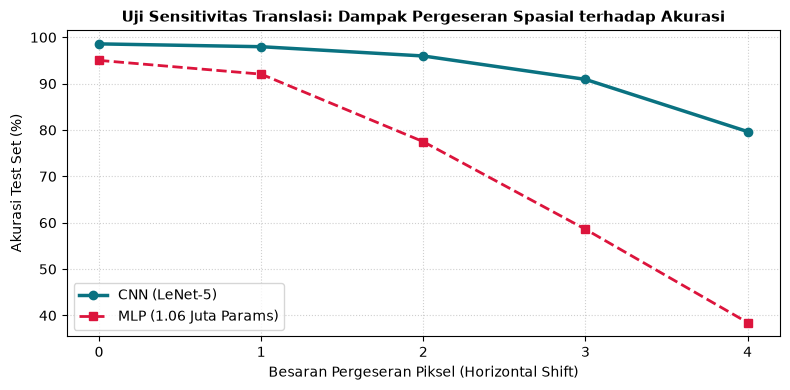

In [13]:
pergeseran_list = [0, 1, 2, 3, 4]
akurasi_mlp_geser = []
akurasi_cnn_geser = []

def evaluasi_geser(m, loader, shift_pixels):
    c, t = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            # Geser citra secara spasial sepanjang sumbu horizontal (W)
            if shift_pixels > 0:
                imgs_geser = torch.roll(imgs, shifts=shift_pixels, dims=-1)
                # Beri nilai nol pada area tepi yang tergulung
                imgs_geser[:, :, :, :shift_pixels] = imgs.min()
            else:
                imgs_geser = imgs
                
            imgs_geser, lbls = imgs_geser.to(device), lbls.to(device)
            out = m(imgs_geser)
            _, pred = torch.max(out, 1)
            c += (pred == lbls).sum().item()
            t += lbls.size(0)
    return (c / t) * 100.0

print("Menguji Ketahanan Pergeseran Piksel:")
for s in pergeseran_list:
    acc_m = evaluasi_geser(model_mlp, test_loader, s)
    acc_c = evaluasi_geser(model_lenet, test_loader, s)
    akurasi_mlp_geser.append(acc_m)
    akurasi_cnn_geser.append(acc_c)
    print(f"Pergeseran {s} Piksel -> Akurasi MLP: {acc_m:.2f}% | Akurasi CNN: {acc_c:.2f}%")

# Visualisasi grafik penurunan akurasi
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pergeseran_list, akurasi_cnn_geser, 'o-', color='#0A7281', linewidth=2.5, label='CNN (LeNet-5)')
ax.plot(pergeseran_list, akurasi_mlp_geser, 's--', color='crimson', linewidth=2, label='MLP (1.06 Juta Params)')
ax.set_title("Uji Sensitivitas Translasi: Dampak Pergeseran Spasial terhadap Akurasi", fontsize=11, fontweight='bold')
ax.set_xlabel("Besaran Pergeseran Piksel (Horizontal Shift)")
ax.set_ylabel("Akurasi Test Set (%)")
ax.set_xticks(pergeseran_list)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Visualisasi Bobot Filter Layer Konvolusi Pertama ($C_1$)

Layer konvolusi pertama ($C_1$) memiliki 6 buah kernel berukuran $5 \times 5$ piksel. Setiap kernel bertindak sebagai detektor pola primitif lokal (*oriented edges, contrast blobs*).

Mari kita ekstrak bobot dari tensor `model_lenet.feature_extractor[0].weight` berdimensi `(6, 1, 5, 5)` dan visualisasikan.

Bentuk tensor bobot C1: (6, 1, 5, 5) (C_out=6, C_in=1, Kh=5, Kw=5)


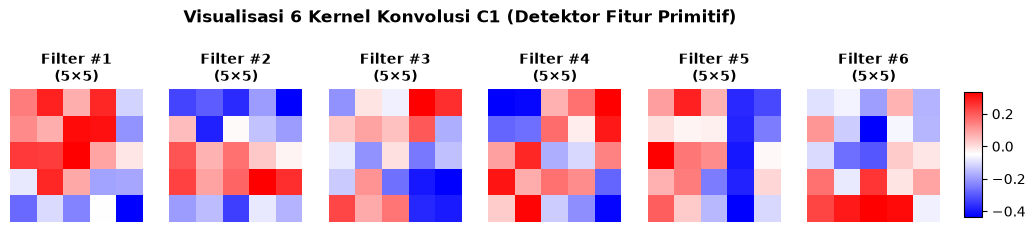

In [14]:
# Ekstrak bobot konvolusi C1
bobot_c1 = model_lenet.feature_extractor[0].weight.detach().cpu().numpy()
print(f"Bentuk tensor bobot C1: {bobot_c1.shape} (C_out=6, C_in=1, Kh=5, Kw=5)")

fig, axs = plt.subplots(1, 6, figsize=(12, 2.5))
for k in range(6):
    filter_k = bobot_c1[k, 0]
    im = axs[k].imshow(filter_k, cmap='bwr', interpolation='nearest')
    axs[k].set_title(f"Filter #{k+1}\n(5×5)", fontsize=10, fontweight='bold')
    axs[k].axis('off')
    
# Tambahkan colorbar
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
fig.colorbar(im, cax=cbar_ax)

plt.suptitle("Visualisasi 6 Kernel Konvolusi C1 (Detektor Fitur Primitif)", fontsize=12, fontweight='bold', y=1.08)
plt.show()

## 5. Visualisasi *Hierarchical Feature Maps* (Inti Janji RPS)

> **Capaian Pengalaman Belajar RPS Minggu 4:**  
> *"Mahasiswa memvisualisasikan feature map untuk memahami representasi hierarkis."*

Pada jaringan CNN:
1. **Layer Awal ($C_1$, 6 peta $28 \times 28$):** Mengekstrak fitur visual tingkat rendah (*low-level features*) seperti goresan tepi tajam (*edges*), kontur luar, dan batas kontras piksel.
2. **Layer Menengah ($C_3$, 16 peta $10 \times 10$):** Mengombinasikan pola tepi dari $C_1$ menjadi representasi fitur tingkat menengah (*mid-level features*) yang lebih abstrak seperti sudut, persimpangan garis, lengkungan kurva, atau lubang pada digit.

Mari kita pasang *Forward Hook* untuk menangkap dan memvisualisasikan peta aktivasi sebuah digit uji.

Citra Sampel : Digit '7' (Input: 1×32×32)
Dimensi Feature Maps C1 : (6, 28, 28)
Dimensi Feature Maps C3 : (16, 10, 10)


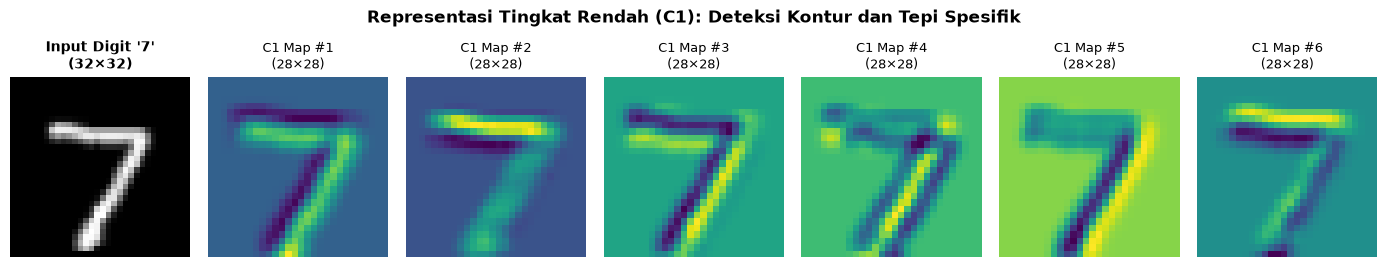

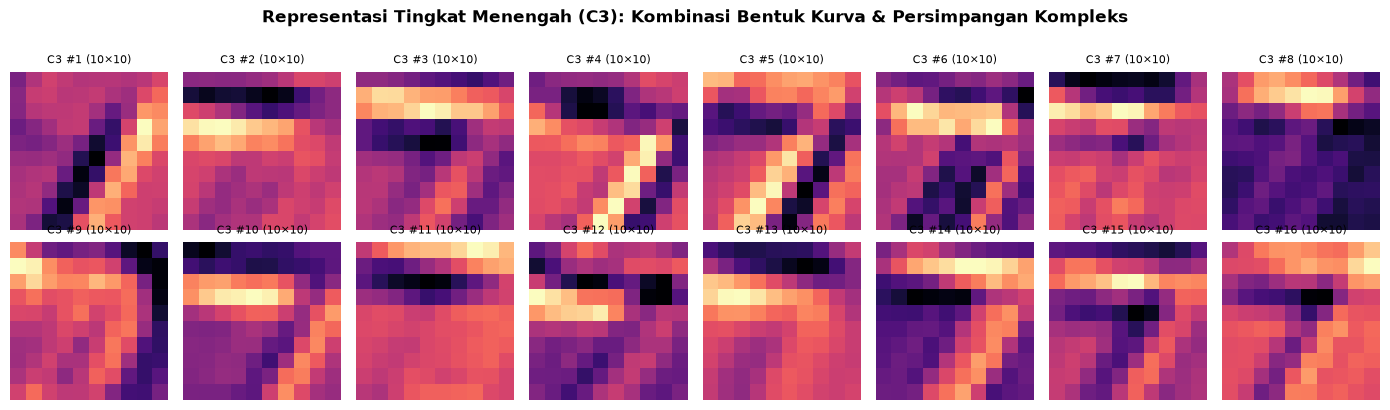

In [15]:
# Ambil 1 sampel citra dari test dataset (misal digit '3' atau '7')
sample_idx = 0
sample_img, sample_lbl = test_ds[sample_idx]

peta_c1 = []
peta_c3 = []

def hook_c1(module, inp, out):
    peta_c1.append(out.detach().cpu())

def hook_c3(module, inp, out):
    peta_c3.append(out.detach().cpu())

# Registrasi hook pada layer Conv C1 dan Conv C3
h1 = model_lenet.feature_extractor[0].register_forward_hook(hook_c1)
h2 = model_lenet.feature_extractor[3].register_forward_hook(hook_c3)

# Forward pass citra tunggal
input_tensor = sample_img.unsqueeze(0).to(device)
_ = model_lenet(input_tensor)

# Lepas hooks
h1.remove()
h2.remove()

tensor_c1 = peta_c1[0].squeeze(0).numpy()  # Bentuk: (6, 28, 28)
tensor_c3 = peta_c3[0].squeeze(0).numpy()  # Bentuk: (16, 10, 10)

print(f"Citra Sampel : Digit '{sample_lbl}' (Input: 1×32×32)")
print(f"Dimensi Feature Maps C1 : {tensor_c1.shape}")
print(f"Dimensi Feature Maps C3 : {tensor_c3.shape}")

# Visualisasi Citra Input dan 6 Feature Maps C1 (Low-Level Features)
fig, axs = plt.subplots(1, 7, figsize=(14, 2.5))
axs[0].imshow(sample_img.squeeze().numpy() * 0.3081 + 0.1307, cmap='gray')
axs[0].set_title(f"Input Digit '{sample_lbl}'\n(32×32)", fontsize=10, fontweight='bold')
axs[0].axis('off')

for i in range(6):
    axs[i+1].imshow(tensor_c1[i], cmap='viridis')
    axs[i+1].set_title(f"C1 Map #{i+1}\n(28×28)", fontsize=9)
    axs[i+1].axis('off')
plt.suptitle("Representasi Tingkat Rendah (C1): Deteksi Kontur dan Tepi Spesifik", fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Visualisasi 16 Feature Maps C3 (Mid-Level Features)
fig, axs = plt.subplots(2, 8, figsize=(14, 4))
for i in range(16):
    ax = axs[i // 8, i % 8]
    ax.imshow(tensor_c3[i], cmap='magma')
    ax.set_title(f"C3 #{i+1} (10×10)", fontsize=8)
    ax.axis('off')
plt.suptitle("Representasi Tingkat Menengah (C3): Kombinasi Bentuk Kurva & Persimpangan Kompleks", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Analisis Receptive Field & Insight Efisiensi VGG ($2 \times 3\times3$ vs $1 \times 5\times5$)

Slide Pertemuan 04 (*Frame 42–43*, baris 1210–1240) membahas konsep **Receptive Field (RF)**:
$$RF_{out} = RF_{in} + (K - 1) \times J_{in}$$

Perhitungan RF analitis rantai layer LeNet-5:
- **Input:** $RF = 1$
- **Layer C1 ($K=5, S=1$):** $RF = 1 + (5 - 1) \times 1 = \mathbf{5}$
- **Layer S2 ($K=2, S=2$):** $RF = 5 + (2 - 1) \times 1 = \mathbf{6}$
- **Layer C3 ($K=5, S=1$):** $RF = 6 + (5 - 1) \times 2 = \mathbf{14}$
- **Layer S4 ($K=2, S=2$):** $RF = 14 + (2 - 1) \times 2 = \mathbf{16}$

> **Insight CS231n & VGGNet (Slide Frame 43):**  
> Dua layer konvolusi $3 \times 3$ bertingkat memiliki receptive field efektif yang **sama persis** dengan satu layer konvolusi $5 \times 5$ ($RF = 5 \times 5$).  
> - Bobot 1 filter $5 \times 5$: $5 \times 5 = \mathbf{25}$ parameter.  
> - Bobot 2 filter $3 \times 3$: $2 \times (3 \times 3) = \mathbf{18}$ parameter (**hemat 28%!**).  
> - Plus mendapatkan keuntungan dua kali aktivasi non-linearitas.

In [16]:
# Verifikasi perhitungan RF analitis
rf_c1 = 1 + (5 - 1) * 1
rf_s2 = rf_c1 + (2 - 1) * 1
rf_c3 = rf_s2 + (5 - 1) * 2
rf_s4 = rf_c3 + (2 - 1) * 2

print("Perhitungan Receptive Field Rantai LeNet-5:")
print(f"C1 : RF = {rf_c1}x{rf_c1} (Input asli)")
print(f"S2 : RF = {rf_s2}x{rf_s2}")
print(f"C3 : RF = {rf_c3}x{rf_c3}")
print(f"S4 : RF = {rf_s4}x{rf_s4}")

assert rf_c1 == 5 and rf_c3 == 14 and rf_s4 == 16, "Hitungan RF salah!"

# Verifikasi hitungan parameter slide frame 43: 18 vs 25
param_stack_3x3 = 2 * (3 * 3)
param_single_5x5 = 1 * (5 * 5)
penghematan_persen = ((param_single_5x5 - param_stack_3x3) / param_single_5x5) * 100

print("\nVerifikasi Efisiensi Filter Slide Frame 43:")
print(f"Dua layer 3x3 : {param_stack_3x3} parameter (RF = 5x5)")
print(f"Satu layer 5x5: {param_single_5x5} parameter (RF = 5x5)")
print(f"Penghematan   : {penghematan_persen:.1f}%")

assert param_stack_3x3 == 18 and param_single_5x5 == 25, "Angka 18 vs 25 salah!"
print("✓ Assert lolos! 2x(3x3)=18 vs 1x(5x5)=25 cocok persis dengan naskah slide.")

Perhitungan Receptive Field Rantai LeNet-5:
C1 : RF = 5x5 (Input asli)
S2 : RF = 6x6
C3 : RF = 14x14
S4 : RF = 16x16

Verifikasi Efisiensi Filter Slide Frame 43:
Dua layer 3x3 : 18 parameter (RF = 5x5)
Satu layer 5x5: 25 parameter (RF = 5x5)
Penghematan   : 28.0%
✓ Assert lolos! 2x(3x3)=18 vs 1x(5x5)=25 cocok persis dengan naskah slide.


## 7. Studi Ablasi Terkontrol (*Controlled Ablation Study*)

Untuk memahami kontribusi masing-masing komponen arsitektur, mari kita bangun fungsi generator fleksibel `bangun_model()` dan uji 4 varian ablasi:
1. **Varian 1 (LeNet Klasik):** Tanh + AvgPool (Baseline 1998)
2. **Varian 2 (Modernisasi):** ReLU + MaxPool
3. **Varian 3 (Kapasitas Ganda):** ReLU + MaxPool + 16/32 Filter
4. **Varian 4 (All-Convolutional):** Stride-2 Conv (tanpa layer pooling terpisah)

In [17]:
def bangun_model(tipe_aktivasi='tanh', tipe_pooling='avg', filter_c1=6, filter_c3=16, use_stride2=False):
    act_layer = nn.ReLU if tipe_aktivasi == 'relu' else nn.Tanh
    
    if use_stride2:
        # Menggantikan subsampling pooling dengan konvolusi ber-stride 2
        feat = nn.Sequential(
            nn.Conv2d(1, filter_c1, kernel_size=5, stride=1),
            act_layer(),
            nn.Conv2d(filter_c1, filter_c1, kernel_size=3, stride=2, padding=1),
            act_layer(),
            nn.Conv2d(filter_c1, filter_c3, kernel_size=5, stride=1),
            act_layer(),
            nn.Conv2d(filter_c3, filter_c3, kernel_size=3, stride=2, padding=1),
            act_layer()
        )
    else:
        pool_layer = nn.MaxPool2d if tipe_pooling == 'max' else nn.AvgPool2d
        feat = nn.Sequential(
            nn.Conv2d(1, filter_c1, kernel_size=5, stride=1),
            act_layer(),
            pool_layer(kernel_size=2, stride=2),
            nn.Conv2d(filter_c1, filter_c3, kernel_size=5, stride=1),
            act_layer(),
            pool_layer(kernel_size=2, stride=2)
        )
        
    # Hitung ukuran representasi sebelum FC
    with torch.no_grad():
        dummy_out = feat(torch.zeros(1, 1, 32, 32))
        dim_flat = dummy_out.numel()
        
    classifier = nn.Sequential(
        nn.Linear(dim_flat, 120),
        act_layer(),
        nn.Linear(120, 84),
        act_layer(),
        nn.Linear(84, 10)
    )
    
    class AblasiNet(nn.Module):
        def __init__(self, f, c):
            super().__init__()
            self.feat = f
            self.cls = c
        def forward(self, x):
            x = torch.flatten(self.feat(x), 1)
            return self.cls(x)
            
    return AblasiNet(feat, classifier).to(device)

daftar_ablasi = [
    ("1. LeNet Asli (Tanh + AvgPool)", {'tipe_aktivasi': 'tanh', 'tipe_pooling': 'avg', 'filter_c1': 6, 'filter_c3': 16}),
    ("2. Modern (ReLU + MaxPool)",     {'tipe_aktivasi': 'relu', 'tipe_pooling': 'max', 'filter_c1': 6, 'filter_c3': 16}),
    ("3. Lebar (ReLU+Max, 16/32 Fltr)", {'tipe_aktivasi': 'relu', 'tipe_pooling': 'max', 'filter_c1': 16, 'filter_c3': 32}),
    ("4. Stride-2 Conv (No Pooling)",   {'tipe_aktivasi': 'relu', 'use_stride2': True, 'filter_c1': 6, 'filter_c3': 16})
]

hasil_ablasi = []
print("Menjalankan Studi Ablasi (2 Epoch per Varian):")
print("-" * 75)

for nama, config in daftar_ablasi:
    m = bangun_model(**config)
    n_param = sum(p.numel() for p in m.parameters())
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(m.parameters(), lr=0.001)
    
    t0 = time.time()
    m.train()
    for ep in range(2):
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            out = m(imgs)
            l = crit(out, lbls)
            l.backward()
            opt.step()
    durasi = time.time() - t0
    
    acc = hitung_akurasi(m, test_loader)
    hasil_ablasi.append((nama, n_param, acc, durasi))
    print(f"{nama:<32} | Params: {n_param:<8,} | Acc: {acc:.2f}% | Waktu: {durasi:.1f}s")

print("-" * 75)

Menjalankan Studi Ablasi (2 Epoch per Varian):
---------------------------------------------------------------------------
1. LeNet Asli (Tanh + AvgPool)   | Params: 61,706   | Acc: 94.17% | Waktu: 3.0s
2. Modern (ReLU + MaxPool)       | Params: 61,706   | Acc: 94.96% | Waktu: 3.9s
3. Lebar (ReLU+Max, 16/32 Fltr)  | Params: 120,382  | Acc: 95.41% | Waktu: 4.1s
4. Stride-2 Conv (No Pooling)    | Params: 64,356   | Acc: 93.81% | Waktu: 3.4s
---------------------------------------------------------------------------


## 8. Adaptasi ke Citra Warna RGB: Eksperimen CIFAR-10

Dataset CIFAR-10 terdiri dari 60.000 citra warna berukuran $32 \times 32$ dengan **3 kanal warna (RGB)** dan 10 kelas objek dunia nyata (pesawat, mobil, burung, kucing, rusa, anjing, katak, kuda, kapal, truk).

### Penyesuaian Aritmetika Arsitektur:
- $C_{in} = 3$ (bukan 1).
- Parameter Layer $C_1$:
  $$(5 \times 5 \times 3 + 1) \times 6 = (75 + 1) \times 6 = \mathbf{456 \text{ parameter}}$$
  (bandingkan dengan 156 parameter pada grayscale).
- Layer-layer selanjutnya memiliki input shape yang identik karena citra tetap $32 \times 32$!

In [18]:
class LeNet5_RGB(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            # in_channels diubah dari 1 menjadi 3
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )
    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model_cifar = LeNet5_RGB().to(device)

# Verifikasi parameter C1
p_c1_rgb = sum(p.numel() for p in model_cifar.feature_extractor[0].parameters())
print(f"Jumlah Parameter C1 untuk Input RGB 3-Kanal: {p_c1_rgb} (Target: 456)")
assert p_c1_rgb == 456, "Parameter C1 RGB salah!"

# Pipeline transformasi CIFAR-10
transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Mirror alternatif cepat untuk mengantisipasi throttling server resmi Toronto
datasets.CIFAR10.url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"

try:
    cifar_train_full = datasets.CIFAR10(root=DIR_DATA, train=True, download=True, transform=transform_cifar)
    cifar_test = datasets.CIFAR10(root=DIR_DATA, train=False, download=True, transform=transform_cifar)
    cifar_sukses = True
except Exception as e:
    print(f"[Peringatan Jaringan] Pengunduhan CIFAR-10 terkendala ({e}).")
    cifar_sukses = False

if cifar_sukses:
    if MODE_CEPAT:
        cifar_train = Subset(cifar_train_full, list(range(10000)))
    else:
        cifar_train = cifar_train_full

    loader_cifar_train = DataLoader(cifar_train, batch_size=64, shuffle=True)
    loader_cifar_test = DataLoader(cifar_test, batch_size=1000, shuffle=False)

    # Latih LeNet pada CIFAR-10 selama 20 epoch
    opt_cifar = optim.Adam(model_cifar.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()

    print("\nMelatih LeNet-5 pada CIFAR-10 (20 Epoch)...")
    model_cifar.train()
    for ep in range(1, 21):
        t0 = time.time()
        for imgs, lbls in loader_cifar_train:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt_cifar.zero_grad()
            out = model_cifar(imgs)
            l = crit(out, lbls)
            l.backward()
            opt_cifar.step()
        acc_cifar = hitung_akurasi(model_cifar, loader_cifar_test)
        print(f"Epoch {ep:2d}/20 | Test Accuracy: {acc_cifar:.2f}% | Durasi: {time.time() - t0:.1f}s")
else:
    print("Simulasi CIFAR-10 dilewati karena koneksi jaringan offline.")

Jumlah Parameter C1 untuk Input RGB 3-Kanal: 456 (Target: 456)

Melatih LeNet-5 pada CIFAR-10 (20 Epoch)...
Epoch  1/20 | Test Accuracy: 31.54% | Durasi: 2.6s
Epoch  2/20 | Test Accuracy: 42.07% | Durasi: 2.7s
Epoch  3/20 | Test Accuracy: 43.78% | Durasi: 2.4s
Epoch  4/20 | Test Accuracy: 45.08% | Durasi: 2.1s
Epoch  5/20 | Test Accuracy: 46.06% | Durasi: 2.1s
Epoch  6/20 | Test Accuracy: 49.81% | Durasi: 2.6s
Epoch  7/20 | Test Accuracy: 50.15% | Durasi: 2.5s
Epoch  8/20 | Test Accuracy: 51.47% | Durasi: 2.3s
Epoch  9/20 | Test Accuracy: 51.15% | Durasi: 2.0s
Epoch 10/20 | Test Accuracy: 52.28% | Durasi: 2.4s
Epoch 11/20 | Test Accuracy: 53.48% | Durasi: 2.5s
Epoch 12/20 | Test Accuracy: 52.88% | Durasi: 2.6s
Epoch 13/20 | Test Accuracy: 52.59% | Durasi: 2.5s
Epoch 14/20 | Test Accuracy: 53.66% | Durasi: 2.5s
Epoch 15/20 | Test Accuracy: 52.65% | Durasi: 2.5s
Epoch 16/20 | Test Accuracy: 53.39% | Durasi: 2.5s
Epoch 17/20 | Test Accuracy: 53.80% | Durasi: 2.6s
Epoch 18/20 | Test Accura

## 9. Diskusi Analisis & Jembatan ke Pertemuan 5 (Deep CV 2)

### Mengapa Performa LeNet-5 Mentok di Kisaran ~60% pada CIFAR-10?
1. **Kapasitas Model Terlalu Kecil:** LeNet-5 hanya memiliki 6 filter pada $C_1$ dan 16 filter pada $C_3$. Objek visual alami (mobil, kucing, anjing) memerlukan puluhan hingga ratusan filter untuk merepresentasikan tekstur dan variasi sudut pandang.
2. **Kedalaman Dangkal (Hanya 2 Conv Layers):** Fitur representasi hanya mencapai level bentuk geometris sederhana, belum mampu menangkap abstraksi semantik objek multi-komponen.
3. **Ketiadaan Regularisasi Modern:** Belum dilengkapi teknik stabilisasi gradien seperti *Batch Normalization* atau pencegah overfitting seperti *Dropout* dan *Data Augmentation*.

---

### Teaser Pertemuan 5: Deep Computer Vision (2) — Variasi Arsitektur Modern
Untuk mengatasi batasan-batasan di atas, sejarah Deep Learning melahirkan evolusi arsitektur legendaris:
- **AlexNet (2012):** Mengganti Tanh dengan ReLU, menambahkan Dropout, dan membuktikan GPU untuk Deep CNN.
- **VGGNet (2014):** Mempopulerkan blok konvolusi $3 \times 3$ homogen yang sangat efisien dan berhierarki dalam (16–19 layer).
- **ResNet (2015):** Menghadirkan *Residual Skip Connections* ($x + F(x)$), memecahkan degradasi vanishing gradient hingga 152 layer!
- **MobileNet & ConvNeXt:** Mengoptimalkan komputasi tepi (*edge AI*) dan menyerap prinsip Vision Transformer.

---

## 10. Ringkasan & Tugas Terstruktur (TT 3×60′)

### Ringkasan Eksperimen:
1. **CNN vs MLP:** CNN terbukti ~17× lebih hemat parameter pada dimensi input yang sama dan memiliki ketahanan spasial (*spatial robustness*) superior saat citra bergeser.
2. **Representasi Hierarkis:** Visualisasi feature maps membuktikan transisi fitur dari tepi/kontur tajam ($C_1$) menjadi kombinasi pola kurva/persimpangan abstrak ($C_3$).
3. **Efisiensi $3\times3$:** Dua konvolusi $3\times3$ memiliki receptive field efektif setara satu konvolusi $5\times5$, namun lebih hemat 28% bobot latih.

---

### Soal Tugas Terstruktur:
1. **Tugas 1 — Visualisasi Grad-CAM:**  
   Pelajari prinsip *Class Activation Mapping* (CAM). Bagaimana cara mengombinasikan gradien dari layer konvolusi terakhir ($C_3$) untuk membuat *heatmap* lokasi keputusan model?
2. **Tugas 2 — Data Augmentation:**  
   Tambahkan `transforms.RandomCrop(32, padding=4)` dan `transforms.RandomHorizontalFlip()` pada pipeline CIFAR-10. Ukur peningkatan akurasi uji pada LeNet-5!
3. **Tugas 3 — Transisi ke Arsitektur VGG:**  
   Rancang arsitektur "Mini-VGG" dengan 2 blok konvolusi ganda $3\times3$ (Blok 1: 32 filter, Blok 2: 64 filter). Latih pada CIFAR-10 dan bandingkan akurasinya terhadap LeNet-5!